# SEIRS-SEI Malaria Model — Weighted M' (Carrying Capacity) Calibration

Calibrating **M_prime** (mosquito carrying capacity base) with **time-weighted optimization** to better fit the initial decline in infected cases.

## Problem Statement

M' sets the mosquito carrying capacity as `K = max(M' * f_T(T) * f_R(R), M_min)`. Larger M' means more mosquitoes, hence more transmission. This calibration uses previously fitted humidity (H0, k, phi), human transmission (tau_H, gamma, omega), force of infection (b1, b2), and initial condition (S_H0, E_H0, I_M0) parameters.

**Parameter being calibrated:**
- **M_prime**: mosquito carrying capacity base (absolute number of mosquitoes)

**K_0 >= M_0 constraint:** The carrying capacity at the start of the main period (2017) must exceed the initial mosquito population, otherwise the parameter set is rejected (`MSE = 1e15`).

**Consistent warm-up:** The warm-up (2012–2016) is re-run with the **same M_prime being tested**, so the 2017 ICs are compatible with the calibrated carrying capacity.

**Weight Decay Methods:**
- **Exponential**: `weight = W0 * exp(-rate * days)` - Smooth, continuous decay
- **Step**: Higher weight for first year, then lower weight
- **Inverse**: `weight = W0 * (1 / (1 + days/365))` - Year-based decay

**Default value**: M' = 40 × N_2012 (≈ 42.6 × N_2017)

---
**Resumable execution**: Results are saved to `calibration_results_mprime.json` after each section.
If the notebook is interrupted, re-run from the top — completed sections will be loaded from file and skipped.

In [2]:
from weighted_optimization_shared import *
%matplotlib inline
import warnings, json, os
warnings.filterwarnings("ignore")
from scipy.optimize import minimize, minimize_scalar
import itertools

Climate data 2012-2023: 4383 days
Warm-up (2012-2016): 1827 days
Main period (2017-2023): 2556 days

IBGE rural population by year (2017-2023):
2017: 8368.62
2018: 8260.48
2019: 8152.73
2020: 8045.43
2021: 7938.61
2022: 7832.33
2023: 7942.25
Loaded fitted human params from exponential: tau_H=21.0000, gamma=0.008333, omega=0.005556

Initial human compartments in 2012: N=8914, S_H=5365, E_H=446, I_H=1766, R_H=1337
Initial mosquito compartments in 2012: M=89140, S_M=85576, E_M=2673, I_M=891
Loaded fitted FoI params from exponential: b1=0.040000, b2=0.090000
Loaded fitted IC params from exponential: S_H0_frac=0.4000, E_H0_frac=0.3500, I_M0_ratio=0.020000


In [3]:
RESULTS_FILE = os.path.join(os.getcwd(), 'calibration_results_mprime.json')

multipliers = [10, 20, 30, 40, 50, 60, 75]
N_2017 = round(pop_by_year[2017])
decay_rate = 0.005
initial_weight = 5.0
step_initial_weight = 5.0
step_later_weight = 1.0
inverse_scale = 365

saved = {}
if os.path.exists(RESULTS_FILE):
    with open(RESULTS_FILE, 'r') as f:
        saved = json.load(f)
    print(f"Loaded saved results from {RESULTS_FILE}")
    for method, params in saved.items():
        print(f"  {method}: M' = {params['multiplier']:.2f} x N (M' = {params['M_prime']:.0f})")
else:
    print("No saved results found — will run all grid searches.")

if 'exponential' in saved:
    M_prime_optimal_exp = saved['exponential']['M_prime']
    multiplier_exp = saved['exponential']['multiplier']
if 'step' in saved:
    M_prime_optimal_step = saved['step']['M_prime']
    multiplier_step = saved['step']['multiplier']
if 'inverse' in saved:
    M_prime_optimal_inv = saved['inverse']['M_prime']
    multiplier_inv = saved['inverse']['multiplier']

No saved results found — will run all grid searches.


In [4]:
def save_result(method_name, M_prime_val, multiplier):
    data = json.load(open(RESULTS_FILE, 'r')) if os.path.exists(RESULTS_FILE) else {}
    data[method_name] = {'M_prime': float(M_prime_val), 'multiplier': float(multiplier)}
    with open(RESULTS_FILE, 'w') as f:
        json.dump(data, f, indent=2)
    print(f"  Saved {method_name} results to {RESULTS_FILE}")

---
## Section 1: Understanding the Weighting Approach

Before calibrating, let's understand how different weight functions affect the optimization.

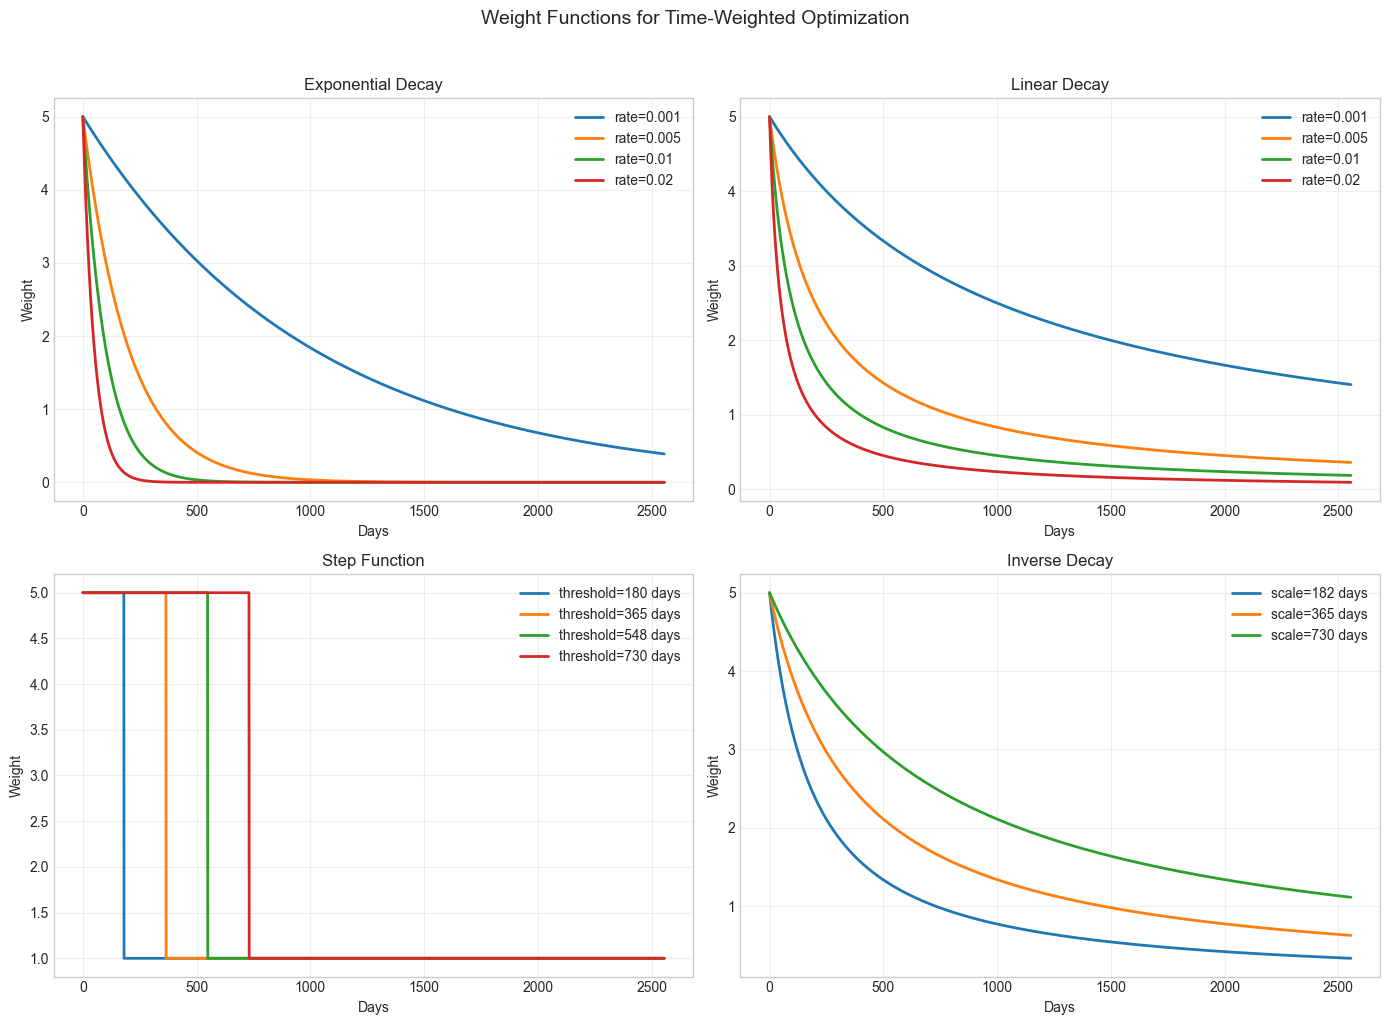

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
days = np.arange(0, 2556, 1)

ax1 = axes[0, 0]
for rate in [0.001, 0.005, 0.01, 0.02]:
    ax1.plot(days, 5.0 * np.exp(-rate * days), linewidth=2, label=f'rate={rate}')
ax1.set_title('Exponential Decay'); ax1.set_xlabel('Days'); ax1.set_ylabel('Weight'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2 = axes[0, 1]
for rate in [0.001, 0.005, 0.01, 0.02]:
    ax2.plot(days, 5.0 / (1 + rate * days), linewidth=2, label=f'rate={rate}')
ax2.set_title('Linear Decay'); ax2.set_xlabel('Days'); ax2.set_ylabel('Weight'); ax2.legend(); ax2.grid(True, alpha=0.3)

ax3 = axes[1, 0]
for thresh in [180, 365, 548, 730]:
    w = np.where(days <= thresh, 5.0, 1.0)
    ax3.plot(days, w, linewidth=2, label=f'threshold={thresh} days')
ax3.set_title('Step Function'); ax3.set_xlabel('Days'); ax3.set_ylabel('Weight'); ax3.legend(); ax3.grid(True, alpha=0.3)

ax4 = axes[1, 1]
for scale in [182, 365, 730]:
    ax4.plot(days, 5.0 * (1.0 / (1.0 + days / scale)), linewidth=2, label=f'scale={scale} days')
ax4.set_title('Inverse Decay'); ax4.set_xlabel('Days'); ax4.set_ylabel('Weight'); ax4.legend(); ax4.grid(True, alpha=0.3)

plt.suptitle('Weight Functions for Time-Weighted Optimization', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Section 2: Grid Search with Exponential Weighting

In [8]:
if 'exponential' not in saved:
    print("=" * 70)
    print("GRID SEARCH: Exponential Weighting")
    print("=" * 70)
    print(f"Grid: M' multipliers {multipliers} x N_2017")
    print(f"Weight: exponential decay, rate={decay_rate}, initial_weight={initial_weight}")
    print()

    best_mult_exp = None
    best_mse_exp = 1e15

    for mult in multipliers:
        M_prime_test = mult * N_2017
        log_mp = np.log(M_prime_test)
        mse = objective_function_weighted_mprime(log_mp,
                                                 weight_decay='exponential',
                                                 decay_rate=decay_rate,
                                                 initial_weight=initial_weight)
        if mse < best_mse_exp:
            best_mse_exp = mse
            best_mult_exp = mult
        print(f"  M' = {mult:>4d} x N = {M_prime_test:>12,.0f} -> Weighted MSE = {mse:>15,.2f}")

    print(f"\nBest from grid (Exponential): M' = {best_mult_exp} x N = {best_mult_exp * N_2017:,.0f}")
    print(f"  Weighted MSE = {best_mse_exp:,.2f}")
else:
    print("Exponential results already loaded — skipping grid search.")
    best_mult_exp = multiplier_exp

GRID SEARCH: Exponential Weighting
Grid: M' multipliers [10, 20, 30, 40, 50, 60, 75] x N_2017
Weight: exponential decay, rate=0.005, initial_weight=5.0

  M' =   10 x N =       83,690 -> Weighted MSE = 1,000,000,000,000,000.00
  M' =   20 x N =      167,380 -> Weighted MSE =    1,462,348.85
  M' =   30 x N =      251,070 -> Weighted MSE =    1,428,711.39
  M' =   40 x N =      334,760 -> Weighted MSE =    1,300,863.71
  M' =   50 x N =      418,450 -> Weighted MSE =    1,009,887.87
  M' =   60 x N =      502,140 -> Weighted MSE =      705,015.22
  M' =   75 x N =      627,675 -> Weighted MSE =      482,435.36

Best from grid (Exponential): M' = 75 x N = 627,675
  Weighted MSE = 482,435.36


In [9]:
if 'exponential' not in saved:
    print("Fine optimization with minimize_scalar (Exponential)...")
    log_low = np.log(best_mult_exp * 0.3 * N_2017)
    log_high = np.log(best_mult_exp * 3.0 * N_2017)
    result_exp = minimize_scalar(
        lambda lp: objective_function_weighted_mprime(lp, weight_decay='exponential',
                                                      decay_rate=decay_rate,
                                                      initial_weight=initial_weight),
        bounds=(log_low, log_high), method='bounded',
        options={'maxiter': 100, 'xatol': 0.01}
    )
    M_prime_optimal_exp = np.exp(result_exp.x)
    multiplier_exp = M_prime_optimal_exp / N_2017
    print(f"  M' = {multiplier_exp:.2f} x N = {M_prime_optimal_exp:,.0f}")
    print(f"  Weighted MSE = {result_exp.fun:,.2f}")
    save_result('exponential', M_prime_optimal_exp, multiplier_exp)
else:
    print(f"Exponential: M' = {multiplier_exp:.2f} x N = {M_prime_optimal_exp:,.0f}")

Fine optimization with minimize_scalar (Exponential)...
  M' = 94.05 x N = 787,082
  Weighted MSE = 481,758.63
  Saved exponential results to C:\Users\rapha\Study_on_malaria_dynamics_v2\models\seirs_sei\weighted_optimization\calibration_results_mprime.json


---
## Section 3: Grid Search with Step Function Weighting

In [11]:
if 'step' not in saved:
    print("=" * 70)
    print("GRID SEARCH: Step Function Weighting")
    print("=" * 70)
    print(f"Grid: M' multipliers {multipliers} x N_2017")
    print(f"Weight: step (first year: {step_initial_weight}x, after: {step_later_weight}x)")
    print()

    best_mult_step = None
    best_mse_step = 1e15

    for mult in multipliers:
        M_prime_test = mult * N_2017
        log_mp = np.log(M_prime_test)
        mse = objective_function_weighted_mprime(log_mp,
                                                 weight_decay='step',
                                                 initial_weight=step_initial_weight,
                                                 step_later_weight=step_later_weight)
        if mse < best_mse_step:
            best_mse_step = mse
            best_mult_step = mult
        print(f"  M' = {mult:>4d} x N = {M_prime_test:>12,.0f} -> Weighted MSE = {mse:>15,.2f}")

    print(f"\nBest from grid (Step): M' = {best_mult_step} x N = {best_mult_step * N_2017:,.0f}")
    print(f"  Weighted MSE = {best_mse_step:,.2f}")
else:
    print("Step results already loaded — skipping grid search.")
    best_mult_step = multiplier_step

GRID SEARCH: Step Function Weighting
Grid: M' multipliers [10, 20, 30, 40, 50, 60, 75] x N_2017
Weight: step (first year: 5.0x, after: 1.0x)

  M' =   10 x N =       83,690 -> Weighted MSE = 1,000,000,000,000,000.00
  M' =   20 x N =      167,380 -> Weighted MSE =      900,025.76
  M' =   30 x N =      251,070 -> Weighted MSE =      883,681.54
  M' =   40 x N =      334,760 -> Weighted MSE =      788,557.24
  M' =   50 x N =      418,450 -> Weighted MSE =      599,973.93
  M' =   60 x N =      502,140 -> Weighted MSE =      608,842.96
  M' =   75 x N =      627,675 -> Weighted MSE =      840,393.95

Best from grid (Step): M' = 50 x N = 418,450
  Weighted MSE = 599,973.93


In [12]:
if 'step' not in saved:
    print("Fine optimization with minimize_scalar (Step)...")
    log_low = np.log(best_mult_step * 0.3 * N_2017)
    log_high = np.log(best_mult_step * 3.0 * N_2017)
    result_step = minimize_scalar(
        lambda lp: objective_function_weighted_mprime(lp, weight_decay='step',
                                                      initial_weight=step_initial_weight,
                                                      step_later_weight=step_later_weight),
        bounds=(log_low, log_high), method='bounded',
        options={'maxiter': 100, 'xatol': 0.01}
    )
    M_prime_optimal_step = np.exp(result_step.x)
    multiplier_step = M_prime_optimal_step / N_2017
    print(f"  M' = {multiplier_step:.2f} x N = {M_prime_optimal_step:,.0f}")
    print(f"  Weighted MSE = {result_step.fun:,.2f}")
    save_result('step', M_prime_optimal_step, multiplier_step)
else:
    print(f"Step: M' = {multiplier_step:.2f} x N = {M_prime_optimal_step:,.0f}")

Fine optimization with minimize_scalar (Step)...
  M' = 53.32 x N = 446,235
  Weighted MSE = 581,960.90
  Saved step results to C:\Users\rapha\Study_on_malaria_dynamics_v2\models\seirs_sei\weighted_optimization\calibration_results_mprime.json


---
## Section 4: Grid Search with Inverse Decay Weighting

In [14]:
if 'inverse' not in saved:
    print("=" * 70)
    print("GRID SEARCH: Inverse Decay Weighting")
    print("=" * 70)
    print(f"Grid: M' multipliers {multipliers} x N_2017")
    print(f"Weight: inverse decay, scale={inverse_scale} days")
    print()

    best_mult_inv = None
    best_mse_inv = 1e15

    for mult in multipliers:
        M_prime_test = mult * N_2017
        log_mp = np.log(M_prime_test)
        mse = objective_function_weighted_mprime(log_mp,
                                                 weight_decay='inverse',
                                                 initial_weight=initial_weight,
                                                 inverse_scale=inverse_scale)
        if mse < best_mse_inv:
            best_mse_inv = mse
            best_mult_inv = mult
        print(f"  M' = {mult:>4d} x N = {M_prime_test:>12,.0f} -> Weighted MSE = {mse:>15,.2f}")

    print(f"\nBest from grid (Inverse): M' = {best_mult_inv} x N = {best_mult_inv * N_2017:,.0f}")
    print(f"  Weighted MSE = {best_mse_inv:,.2f}")
else:
    print("Inverse results already loaded — skipping grid search.")
    best_mult_inv = multiplier_inv

GRID SEARCH: Inverse Decay Weighting
Grid: M' multipliers [10, 20, 30, 40, 50, 60, 75] x N_2017
Weight: inverse decay, scale=365 days

  M' =   10 x N =       83,690 -> Weighted MSE = 1,000,000,000,000,000.00
  M' =   20 x N =      167,380 -> Weighted MSE =    1,036,919.24
  M' =   30 x N =      251,070 -> Weighted MSE =    1,019,189.82
  M' =   40 x N =      334,760 -> Weighted MSE =      910,094.91
  M' =   50 x N =      418,450 -> Weighted MSE =      650,450.92
  M' =   60 x N =      502,140 -> Weighted MSE =      584,563.94
  M' =   75 x N =      627,675 -> Weighted MSE =      853,477.82

Best from grid (Inverse): M' = 60 x N = 502,140
  Weighted MSE = 584,563.94


In [15]:
if 'inverse' not in saved:
    print("Fine optimization with minimize_scalar (Inverse)...")
    log_low = np.log(best_mult_inv * 0.3 * N_2017)
    log_high = np.log(best_mult_inv * 3.0 * N_2017)
    result_inv = minimize_scalar(
        lambda lp: objective_function_weighted_mprime(lp, weight_decay='inverse',
                                                      initial_weight=initial_weight,
                                                      inverse_scale=inverse_scale),
        bounds=(log_low, log_high), method='bounded',
        options={'maxiter': 100, 'xatol': 0.01}
    )
    M_prime_optimal_inv = np.exp(result_inv.x)
    multiplier_inv = M_prime_optimal_inv / N_2017
    print(f"  M' = {multiplier_inv:.2f} x N = {M_prime_optimal_inv:,.0f}")
    print(f"  Weighted MSE = {result_inv.fun:,.2f}")
    save_result('inverse', M_prime_optimal_inv, multiplier_inv)
else:
    print(f"Inverse: M' = {multiplier_inv:.2f} x N = {M_prime_optimal_inv:,.0f}")

Fine optimization with minimize_scalar (Inverse)...
  M' = 56.20 x N = 470,368
  Weighted MSE = 580,348.86
  Saved inverse results to C:\Users\rapha\Study_on_malaria_dynamics_v2\models\seirs_sei\weighted_optimization\calibration_results_mprime.json


---
## Section 5: Comparison of All Weighting Methods

Compare the results from exponential, step, and inverse decay weighting, as well as the default M' and unweighted optimization.

In [17]:
print("Running simulations for comparison...")

print("\nRunning unweighted grid search + fine optimization...")
best_mult_unw = None
best_mse_unw = 1e15
for mult in multipliers:
    M_prime_test = mult * N_2017
    mse = objective_function_unweighted_mprime(np.log(M_prime_test))
    if mse < best_mse_unw:
        best_mse_unw = mse
        best_mult_unw = mult
    print(f"  M' = {mult:>4d} x N = {M_prime_test:>12,.0f} -> MSE = {mse:>15,.2f}")
log_low = np.log(best_mult_unw * 0.3 * N_2017)
log_high = np.log(best_mult_unw * 3.0 * N_2017)
result_unw = minimize_scalar(objective_function_unweighted_mprime,
                             bounds=(log_low, log_high), method='bounded',
                             options={'maxiter': 100, 'xatol': 0.01})
M_prime_opt_unw = np.exp(result_unw.x)
multiplier_unw = M_prime_opt_unw / N_2017
print(f"Unweighted: M' = {multiplier_unw:.2f} x N = {M_prime_opt_unw:,.0f}")

print("\nRunning default simulation...")
dates_default, IH_default = run_with_mprime(M_prime_warmup)
print(f"Default: M' = {M_prime_warmup:,.0f} ({M_prime_warmup / N_2017:.2f} x N)")

print("\nRunning unweighted simulation...")
dates_unw, IH_unw = run_with_mprime(M_prime_opt_unw)
print(f"Unweighted: M' = {multiplier_unw:.2f} x N")

print("\nRunning exponential weighting...")
dates_exp, IH_exp = run_with_mprime(M_prime_optimal_exp)
print(f"Exponential: M' = {multiplier_exp:.2f} x N")

print("\nRunning step function weighting...")
dates_step, IH_step = run_with_mprime(M_prime_optimal_step)
print(f"Step: M' = {multiplier_step:.2f} x N")

print("\nRunning inverse decay weighting...")
dates_inv, IH_inv = run_with_mprime(M_prime_optimal_inv)
print(f"Inverse: M' = {multiplier_inv:.2f} x N")

print("\nAll simulations completed!")

Running simulations for comparison...

Running unweighted grid search + fine optimization...
  M' =   10 x N =       83,690 -> MSE = 1,000,000,000,000,000.00
  M' =   20 x N =      167,380 -> MSE =      731,657.51
  M' =   30 x N =      251,070 -> MSE =      721,684.78
  M' =   40 x N =      334,760 -> MSE =      631,769.34
  M' =   50 x N =      418,450 -> MSE =      464,233.51
  M' =   60 x N =      502,140 -> MSE =      607,281.51
  M' =   75 x N =      627,675 -> MSE =    1,098,432.34
Unweighted: M' = 47.79 x N = 399,932

Running default simulation...
Default: M' = 356,560 (42.60 x N)

Running unweighted simulation...
Unweighted: M' = 47.79 x N

Running exponential weighting...
Exponential: M' = 94.05 x N

Running step function weighting...
Step: M' = 53.32 x N

Running inverse decay weighting...
Inverse: M' = 56.20 x N

All simulations completed!


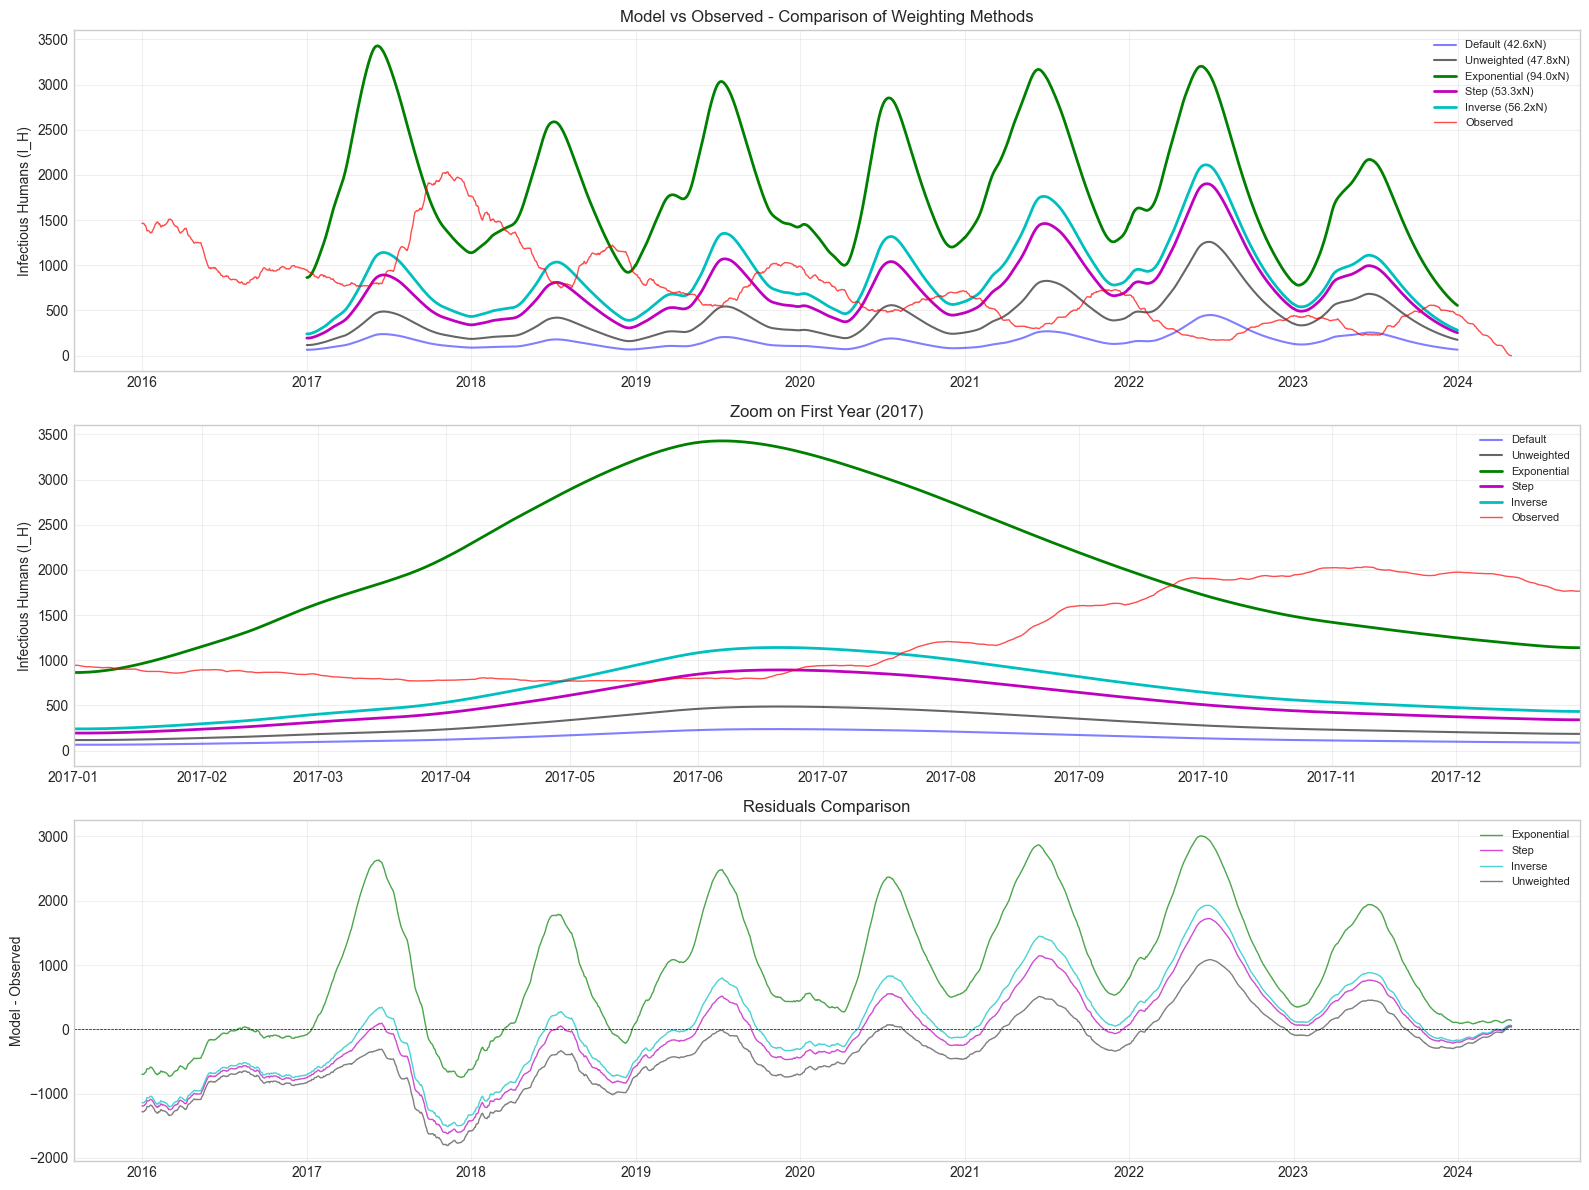

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

ax1 = axes[0]
ax1.plot(pd.to_datetime(dates_default), IH_default, 'b-', linewidth=1.5, alpha=0.5,
         label=f'Default ({M_prime_warmup / N_2017:.1f}xN)')
ax1.plot(pd.to_datetime(dates_unw), IH_unw, 'k-', linewidth=1.5, alpha=0.6,
         label=f'Unweighted ({multiplier_unw:.1f}xN)')
ax1.plot(pd.to_datetime(dates_exp), IH_exp, 'g-', linewidth=2,
         label=f'Exponential ({multiplier_exp:.1f}xN)')
ax1.plot(pd.to_datetime(dates_step), IH_step, 'm-', linewidth=2,
         label=f'Step ({multiplier_step:.1f}xN)')
ax1.plot(pd.to_datetime(dates_inv), IH_inv, 'c-', linewidth=2,
         label=f'Inverse ({multiplier_inv:.1f}xN)')
ax1.plot(rural_cases_df['date'], rural_cases_df['active_total'], 'r-', linewidth=1.0, alpha=0.7, label='Observed')
ax1.set_ylabel('Infectious Humans (I_H)'); ax1.set_title('Model vs Observed - Comparison of Weighting Methods')
ax1.legend(loc='upper right', fontsize=8); ax1.grid(True, alpha=0.3)

ax2 = axes[1]
first_year_end = pd.to_datetime('2017-12-31')
ax2.plot(pd.to_datetime(dates_default), IH_default, 'b-', linewidth=1.5, alpha=0.5, label='Default')
ax2.plot(pd.to_datetime(dates_unw), IH_unw, 'k-', linewidth=1.5, alpha=0.6, label='Unweighted')
ax2.plot(pd.to_datetime(dates_exp), IH_exp, 'g-', linewidth=2, label='Exponential')
ax2.plot(pd.to_datetime(dates_step), IH_step, 'm-', linewidth=2, label='Step')
ax2.plot(pd.to_datetime(dates_inv), IH_inv, 'c-', linewidth=2, label='Inverse')
ax2.plot(rural_cases_df['date'], rural_cases_df['active_total'], 'r-', linewidth=1.0, alpha=0.7, label='Observed')
ax2.set_xlim(pd.to_datetime('2017-01-01'), first_year_end)
ax2.set_ylabel('Infectious Humans (I_H)'); ax2.set_title('Zoom on First Year (2017)')
ax2.legend(loc='upper right', fontsize=8); ax2.grid(True, alpha=0.3)

ax3 = axes[2]
obs_dates_int = rural_cases_df['date'].astype(np.int64).values
for dates_arr, IH_arr, label, color, alpha in [
    (dates_exp, IH_exp, 'Exponential', 'g', 0.7),
    (dates_step, IH_step, 'Step', 'm', 0.7),
    (dates_inv, IH_inv, 'Inverse', 'c', 0.7),
    (dates_unw, IH_unw, 'Unweighted', 'k', 0.5),
]:
    mi = interp1d(pd.to_datetime(dates_arr).astype(np.int64), IH_arr, kind='linear', fill_value='extrapolate')
    ax3.plot(rural_cases_df['date'], mi(obs_dates_int) - rural_cases_df['active_total'].values,
             '-', color=color, linewidth=1.0, alpha=alpha, label=label)
ax3.axhline(0, color='k', linestyle='--', linewidth=0.5)
ax3.set_ylabel('Model - Observed'); ax3.set_title('Residuals Comparison')
ax3.legend(loc='upper right', fontsize=8); ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Section 6: Quantitative Comparison

In [20]:
def compute_mse(dates, IH):
    mi = interp1d(pd.to_datetime(dates).astype(np.int64), IH, kind='linear', fill_value='extrapolate')
    return np.mean((mi(rural_cases_df['date'].astype(np.int64).values) - rural_cases_df['active_total'].values) ** 2)

def compute_first_year_mse(dates, IH):
    mi = interp1d(pd.to_datetime(dates).astype(np.int64), IH, kind='linear', fill_value='extrapolate')
    mask = rural_cases_df['date'] <= pd.to_datetime('2017-12-31')
    return np.mean((mi(rural_cases_df.loc[mask, 'date'].astype(np.int64).values) - rural_cases_df.loc[mask, 'active_total'].values) ** 2)

method_results = {
    'Default':     {'dates': dates_default, 'IH': IH_default, 'M_prime': M_prime_warmup, 'multiplier': M_prime_warmup / N_2017},
    'Unweighted':  {'dates': dates_unw,     'IH': IH_unw,     'M_prime': M_prime_opt_unw, 'multiplier': multiplier_unw},
    'Exponential': {'dates': dates_exp,     'IH': IH_exp,     'M_prime': M_prime_optimal_exp, 'multiplier': multiplier_exp},
    'Step':        {'dates': dates_step,    'IH': IH_step,    'M_prime': M_prime_optimal_step, 'multiplier': multiplier_step},
    'Inverse':     {'dates': dates_inv,     'IH': IH_inv,     'M_prime': M_prime_optimal_inv, 'multiplier': multiplier_inv},
}

print("=" * 80)
print("QUANTITATIVE COMPARISON")
print("=" * 80)
print(f"{'Method':<15} {'Overall MSE':>15} {'First Year MSE':>15} {'M_prime':>12} {'Mult':>8}")
print("-" * 80)

for name, data in method_results.items():
    overall = compute_mse(data['dates'], data['IH'])
    first_yr = compute_first_year_mse(data['dates'], data['IH'])
    print(f"{name:<15} {overall:>15,.2f} {first_yr:>15,.2f} {data['M_prime']:>12,.0f} {data['multiplier']:>8.2f}")

print("=" * 80)

QUANTITATIVE COMPARISON
Method              Overall MSE  First Year MSE      M_prime     Mult
--------------------------------------------------------------------------------
Default              568,596.72    1,255,235.22      356,560    42.60
Unweighted           473,619.43    1,056,306.73      399,932    47.79
Exponential        1,753,985.47    1,048,632.05      787,082    94.05
Step                 482,022.06      809,038.87      446,235    53.32
Inverse              528,576.18      698,688.33      470,368    56.20


---
## Summary: Best Parameters

In [22]:
saved = json.load(open(RESULTS_FILE, 'r')) if os.path.exists(RESULTS_FILE) else {}

print("=" * 70)
print("BEST WEIGHTED PARAMETERS (M' — Mosquito Carrying Capacity)")
print("=" * 70)
print(f"Population N (2017): {N_2017:,}")
print(f"M_min: {M_min:,}")

for method in ['exponential', 'step', 'inverse']:
    params = saved.get(method, {})
    if params:
        print(f"\n{method.upper()}:")
        print(f"  M' = {params['M_prime']:,.0f}  ({params['multiplier']:.2f} x N_2017)")

print("\n" + "=" * 70)

BEST WEIGHTED PARAMETERS (M' — Mosquito Carrying Capacity)
Population N (2017): 8,369
M_min: 50,000

EXPONENTIAL:
  M' = 787,082  (94.05 x N_2017)

STEP:
  M' = 446,235  (53.32 x N_2017)

INVERSE:
  M' = 470,368  (56.20 x N_2017)

